In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  




In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from region import Region
from functions import Functions
fns = Functions()

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from cartopy.feature import LAND
from scipy.stats import pearsonr


In [4]:
elevation_ = GEBCO(coarsen_factor=4).ds.elevation

In [5]:
sla_ = SLA(deg=0.25).da
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = xr.open_dataarray('sam.nc').sel(time=slice(sla_.time[0],winds_.time[-1]))
dotds = DOT(ver='egm').ds.rename({'ug':'u10','vg':'v10'})
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
sip_ = xr.open_dataarray('sip.nc')

lwe_ds = GRACE().ds
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=dotds.dot,#sla_,#SLA(deg=1).da,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha().sel(time=slice(dotds.time[0],pd.Timestamp(2024,1,1)))



In [6]:
gyre_index = xr.open_dataarray('gyre_index.nc')

In [7]:
extent_ac = [138,152,-68,-63]
extent_ea = [60,160,-70,-60]
extent_sip= [140,146,-67,-66.5]

elevation_ea = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))
elevation_ac = elevation_.sel(latitude = slice(extent_ac[2], extent_ac[3]), longitude = slice(extent_ac[0],extent_ac[1]))

In [8]:
sip_.load()

<xarray.DataArray (time: 174, index: 7443)> Size: 10MB
array([[0.      , 0.      , 0.      , ..., 0.66075 , 0.706299, 0.622608],
       [0.      , 0.      , 0.      , ..., 0.301758, 0.601084, 0.798559],
       [0.      , 0.      , 0.      , ..., 0.432193, 0.550932, 0.427434],
       ...,
       [0.      , 0.      , 0.      , ..., 0.779148, 0.704398, 0.774911],
       [0.      , 0.      , 0.      , ..., 0.177497, 0.262051, 0.233732],
       [0.      , 0.      , 0.      , ..., 0.296595, 0.299498, 0.323815]],
      shape=(174, 7443))
Coordinates:
  * time       (time) datetime64[ns] 1kB 2002-07-01 2002-08-01 ... 2024-10-01
    month      (time) int64 1kB 7 8 9 10 3 4 5 6 7 8 9 ... 9 10 3 4 5 6 7 8 9 10
  * index      (index) int64 60kB 0 1 2 3 4 5 ... 7437 7438 7439 7440 7441 7442
    lat        (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    lon        (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    latitude   (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    longitude  (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    elevation  (index) float64 60kB nan -290.2 -464.2 ... nan -3.251e+03

In [9]:
sip = sip_.where((sip_.lon > extent_ac[0]) & (sip_.lon < extent_ac[1]) &  (sip_.lat > extent_ac[2]) & (sip_.lat < extent_ac[3]))

In [10]:
sip

<xarray.DataArray (time: 174, index: 7443)> Size: 10MB
array([[     nan,      nan,      nan, ..., 0.66075 , 0.706299, 0.622608],
       [     nan,      nan,      nan, ..., 0.301758, 0.601084, 0.798559],
       [     nan,      nan,      nan, ..., 0.432193, 0.550932, 0.427434],
       ...,
       [     nan,      nan,      nan, ..., 0.779148, 0.704398, 0.774911],
       [     nan,      nan,      nan, ..., 0.177497, 0.262051, 0.233732],
       [     nan,      nan,      nan, ..., 0.296595, 0.299498, 0.323815]],
      shape=(174, 7443))
Coordinates:
  * time       (time) datetime64[ns] 1kB 2002-07-01 2002-08-01 ... 2024-10-01
    month      (time) int64 1kB 7 8 9 10 3 4 5 6 7 8 9 ... 9 10 3 4 5 6 7 8 9 10
  * index      (index) int64 60kB 0 1 2 3 4 5 ... 7437 7438 7439 7440 7441 7442
    lat        (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    lon        (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    latitude   (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    longitude  (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    elevation  (index) float64 60kB nan -290.2 -464.2 ... nan -3.251e+03

In [11]:
region_ac = Region('AC',extent_ac,elevation=elevation_ac)
region_ac_shelf = Region('ACS',extent_ac,elevation=elevation_ac,min_elevation=-1000)
region_ea = Region('EA',extent_ea)

extent_gyre = [145,149,-66.5,-65.5]
region_gyre = Region('Gyre',extent=extent_gyre)

region_sip = Region('SIP',extent_sip)

winds_ea = region_ea.crop_da(winds_)

sla = region_ac.crop_da(sla_)
sla_shelf = region_ac_shelf.crop_da(sla_)
sla_gyre = region_gyre.crop_da(sla_)
winds = region_ac.crop_da(winds_)
dot =region_ac.crop_da(dotds)
sice = region_ac.crop_da(sice_)
sic_sip = region_sip.crop_da(sice_)
sip_shelf = sip.where(sip.elevation > -1000,drop=True)
lwe_shelf = region_ac_shelf.crop_da(lwe_ds)
sha_sip = region_sip.crop_da(sha_ds_sla)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

In [12]:
u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [13]:
sa_sla = fns.seasonal_anomaly(sla.interpolate_na(dim='time'))
sa_geos = fns.seasonal_anomaly(geos.interpolate_na(dim='time'))
sa_winds = fns.seasonal_anomaly(winds.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sic = fns.seasonal_anomaly(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
sa_sics = fns.seasonal_anomaly(sic_sip.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))

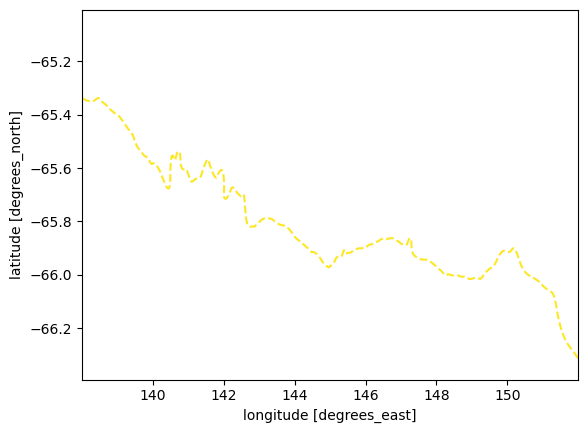

In [14]:
cc=elevation_ac.sel(latitude=slice(-66.4,-65)).plot.contour(levels=[-1000])

In [15]:
lats = xr.DataArray(cc.allsegs[0][0].T[1],coords={'longitude':cc.allsegs[0][0].T[0]})
asclats = lats.sortby('longitude').interp(longitude=geos.longitude,kwargs={'fill_value':'extrapolate'})

In [16]:
# isolate asc on slope = -1000
geos['asc_latitude'] = xr.DataArray(asclats,coords={'longitude':geos.longitude})
geos['asc'] = geos.u10.sel(latitude=geos.asc_latitude,method='nearest')

In [17]:
R = 6371000
lat_radians = np.deg2rad(geos.asc_latitude)

dx = R * np.cos(lat_radians[:-1]) * np.deg2rad(np.diff(geos.longitude))
dy = R * np.deg2rad(np.diff(geos.asc_latitude))

delta = np.stack([dx,dy],axis=1)
t_hat = delta / np.linalg.norm(delta, axis=1)[:, None]

In [18]:
# Interpolate u and v onto path points for all times
u_path = geos.u10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
v_path = geos.v10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
# We project using the unit vector of each segment; use the starting point of each segment
u_seg = u_path[:, :-1]  # drop last point (segments)
v_seg = v_path[:-1, :]

In [19]:
dathatx = xr.DataArray(t_hat[:,0],coords={'longitude':u_seg.longitude})
dathaty = xr.DataArray(t_hat[:,1],coords={'longitude':u_seg.longitude})
v_along = u_seg * dathatx + v_seg * dathaty # shape: (time, segments)

In [20]:
# strength of easterlies and westerlies
def windstrength(data,minlat,maxlat):
    westerly_range = data.sel(latitude=slice(minlat,maxlat))
    weights = np.cos(np.deg2rad(westerly_range.latitude))
    return westerly_range.weighted(weights).mean(dim=["latitude", "longitude"])

eastl = -windstrength(winds.u10,-68,-64)#-winds.u10.sel(latitude=slice(-68,-65)).mean(['latitude','longitude'])
westl = windstrength(winds.u10,-65,-55)#winds.u10.sel(latitude=slice(-64,-55)).mean(['latitude','longitude'])
# strength of ASC/ACC
#asc = geos.u10.sel(latitude=slice(-66.25,-65.5)).mean(['latitude','longitude'])
acc = windstrength(geos.u10,-65,-63)#geos.u10.sel(latitude=slice(-65,-63)).mean(['latitude','longitude'])
# coastal ssh
cssh = sla_shelf.mean(['latitude','longitude'])
csic = sic_sip.mean(['latitude','longitude'])
gssh = sla_gyre.mean(['latitude','longitude'])
# sha & grace
csha = sha_sip.sha.mean(['latitude','longitude'])
clwe = lwe_shelf.lwe_thickness.mean(['latitude','longitude'])
csip = sip_shelf.mean('index').broadcast_like(csha.time)

In [21]:
# new asc
asc = -v_along.mean('longitude')

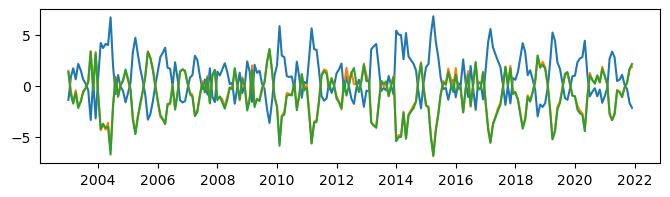

In [22]:
fig,ax = plt.subplots(figsize=(8,2))
ax.plot(geos.time,asc)
ax.plot(geos.time,geos.asc.mean('longitude'))
ax.plot(geos.time,v_along.mean('longitude'))

In [23]:
colors = plt.cm.tab20b(np.linspace(0, 0.75, 4))


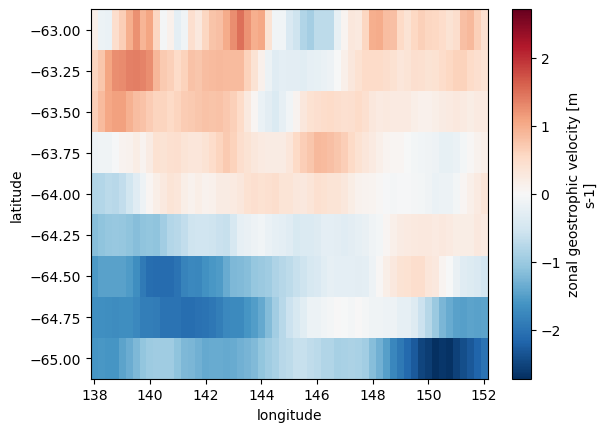

In [24]:
geos.u10.sel(latitude=slice(-65,-63)).mean('time').plot()

Rendering..


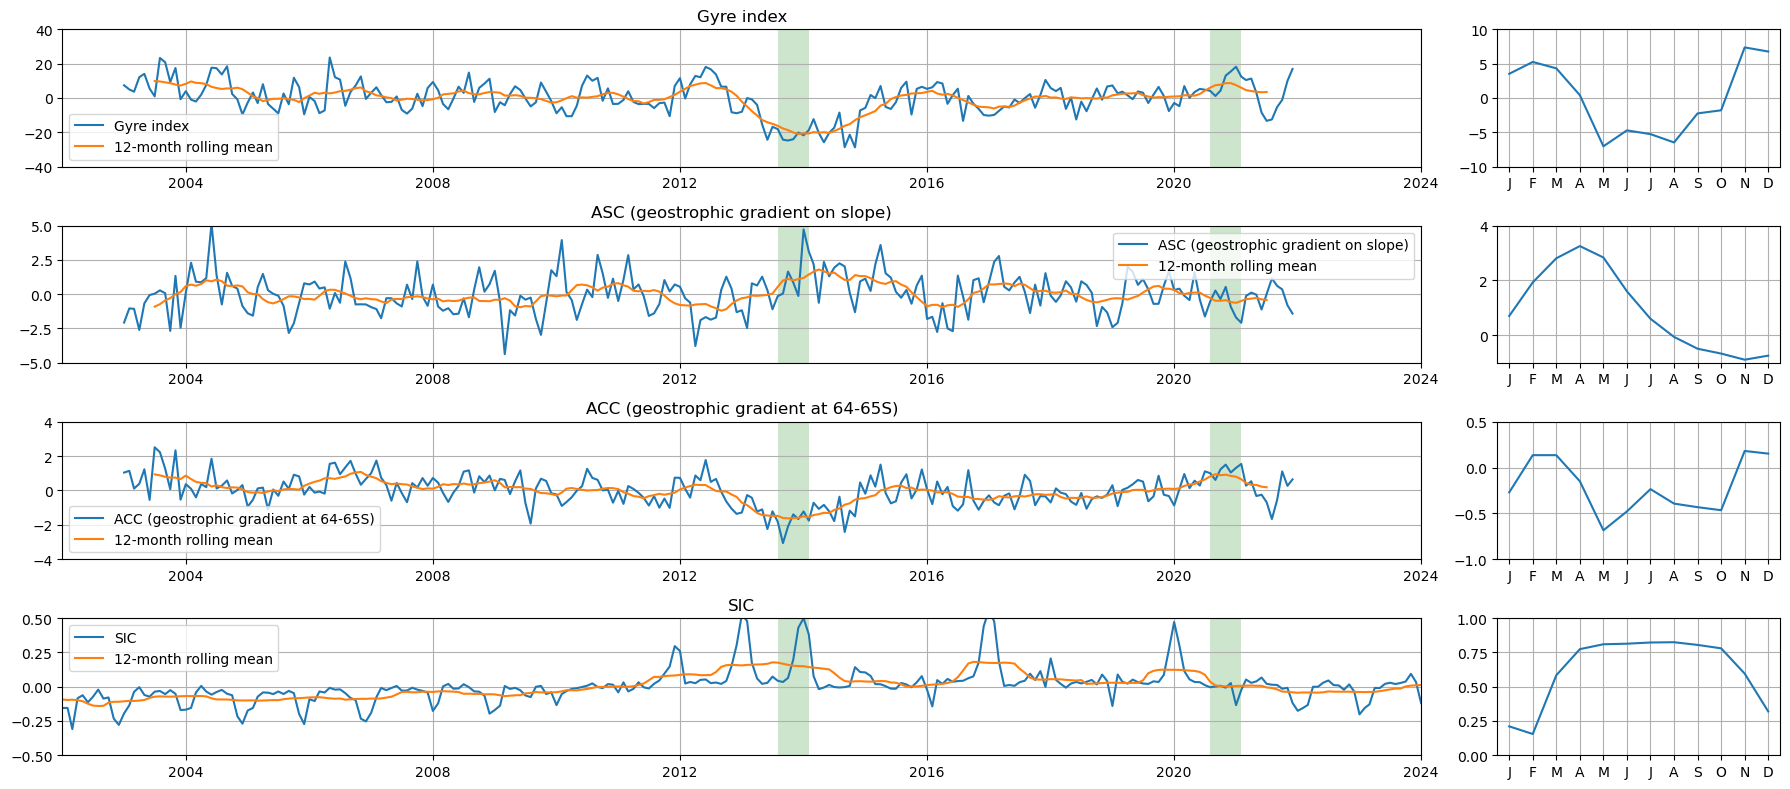

In [25]:
fig = plt.figure(figsize=(18,8))
axs=[]

gs = fig.add_gridspec(4,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    # for y,c in zip([2007,2011,2014,2017],colors):
    #     t1a = pd.Timestamp(y,10,1)
    #     t1b = pd.Timestamp(y+1,1,1)
    #     tboo = (da.time > t1a) & (da.time < t1b)
        
    #     ax.fill_between(da.time, ylim[0],ylim[1], where=tboo, alpha=0.4, facecolor=c,label='spring '+str(y))

    for y in [2013,2020]: 
        #if y==2014:
        t1a = pd.Timestamp(y,7,1)
        t1b = pd.Timestamp(y+1,3,1)
        # else:
        #     t1a = pd.Timestamp(y,1,1)
        #     t1b = pd.Timestamp(y+1,1,1)
        tboo = (da.time > t1a) & (da.time < t1b)
        
        ax.fill_between(da.time, ylim[0],ylim[1], where=tboo, alpha=0.2, facecolor='green',label='spring '+str(y))

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])




add_row(0,gyre_index,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-10,10])
add_row(1,asc,'ASC (geostrophic gradient on slope)',anom=True,ylim=[-5,5],ylim_cmt=[-1,4])
add_row(2,acc,'ACC (geostrophic gradient at 64-65S)',anom=True,ylim=[-4,4],ylim_cmt=[-1,0.5])
add_row(3,csic,'SIC',anom=True,ylim=[-0.5,0.5],ylim_cmt=[0,1])





plt.tight_layout()
print('Rendering..')


In [26]:
sip

<xarray.DataArray (time: 174, index: 7443)> Size: 10MB
array([[     nan,      nan,      nan, ..., 0.66075 , 0.706299, 0.622608],
       [     nan,      nan,      nan, ..., 0.301758, 0.601084, 0.798559],
       [     nan,      nan,      nan, ..., 0.432193, 0.550932, 0.427434],
       ...,
       [     nan,      nan,      nan, ..., 0.779148, 0.704398, 0.774911],
       [     nan,      nan,      nan, ..., 0.177497, 0.262051, 0.233732],
       [     nan,      nan,      nan, ..., 0.296595, 0.299498, 0.323815]],
      shape=(174, 7443))
Coordinates:
  * time       (time) datetime64[ns] 1kB 2002-07-01 2002-08-01 ... 2024-10-01
    month      (time) int64 1kB 7 8 9 10 3 4 5 6 7 8 9 ... 9 10 3 4 5 6 7 8 9 10
  * index      (index) int64 60kB 0 1 2 3 4 5 ... 7437 7438 7439 7440 7441 7442
    lat        (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    lon        (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    latitude   (index) float64 60kB -69.98 -69.97 -69.93 ... -65.01 -65.02
    longitude  (index) float64 60kB 138.0 138.2 138.1 ... 149.7 149.6 149.9
    elevation  (index) float64 60kB nan -290.2 -464.2 ... nan -3.251e+03

In [27]:
len(axs)-1

7

Rendering..


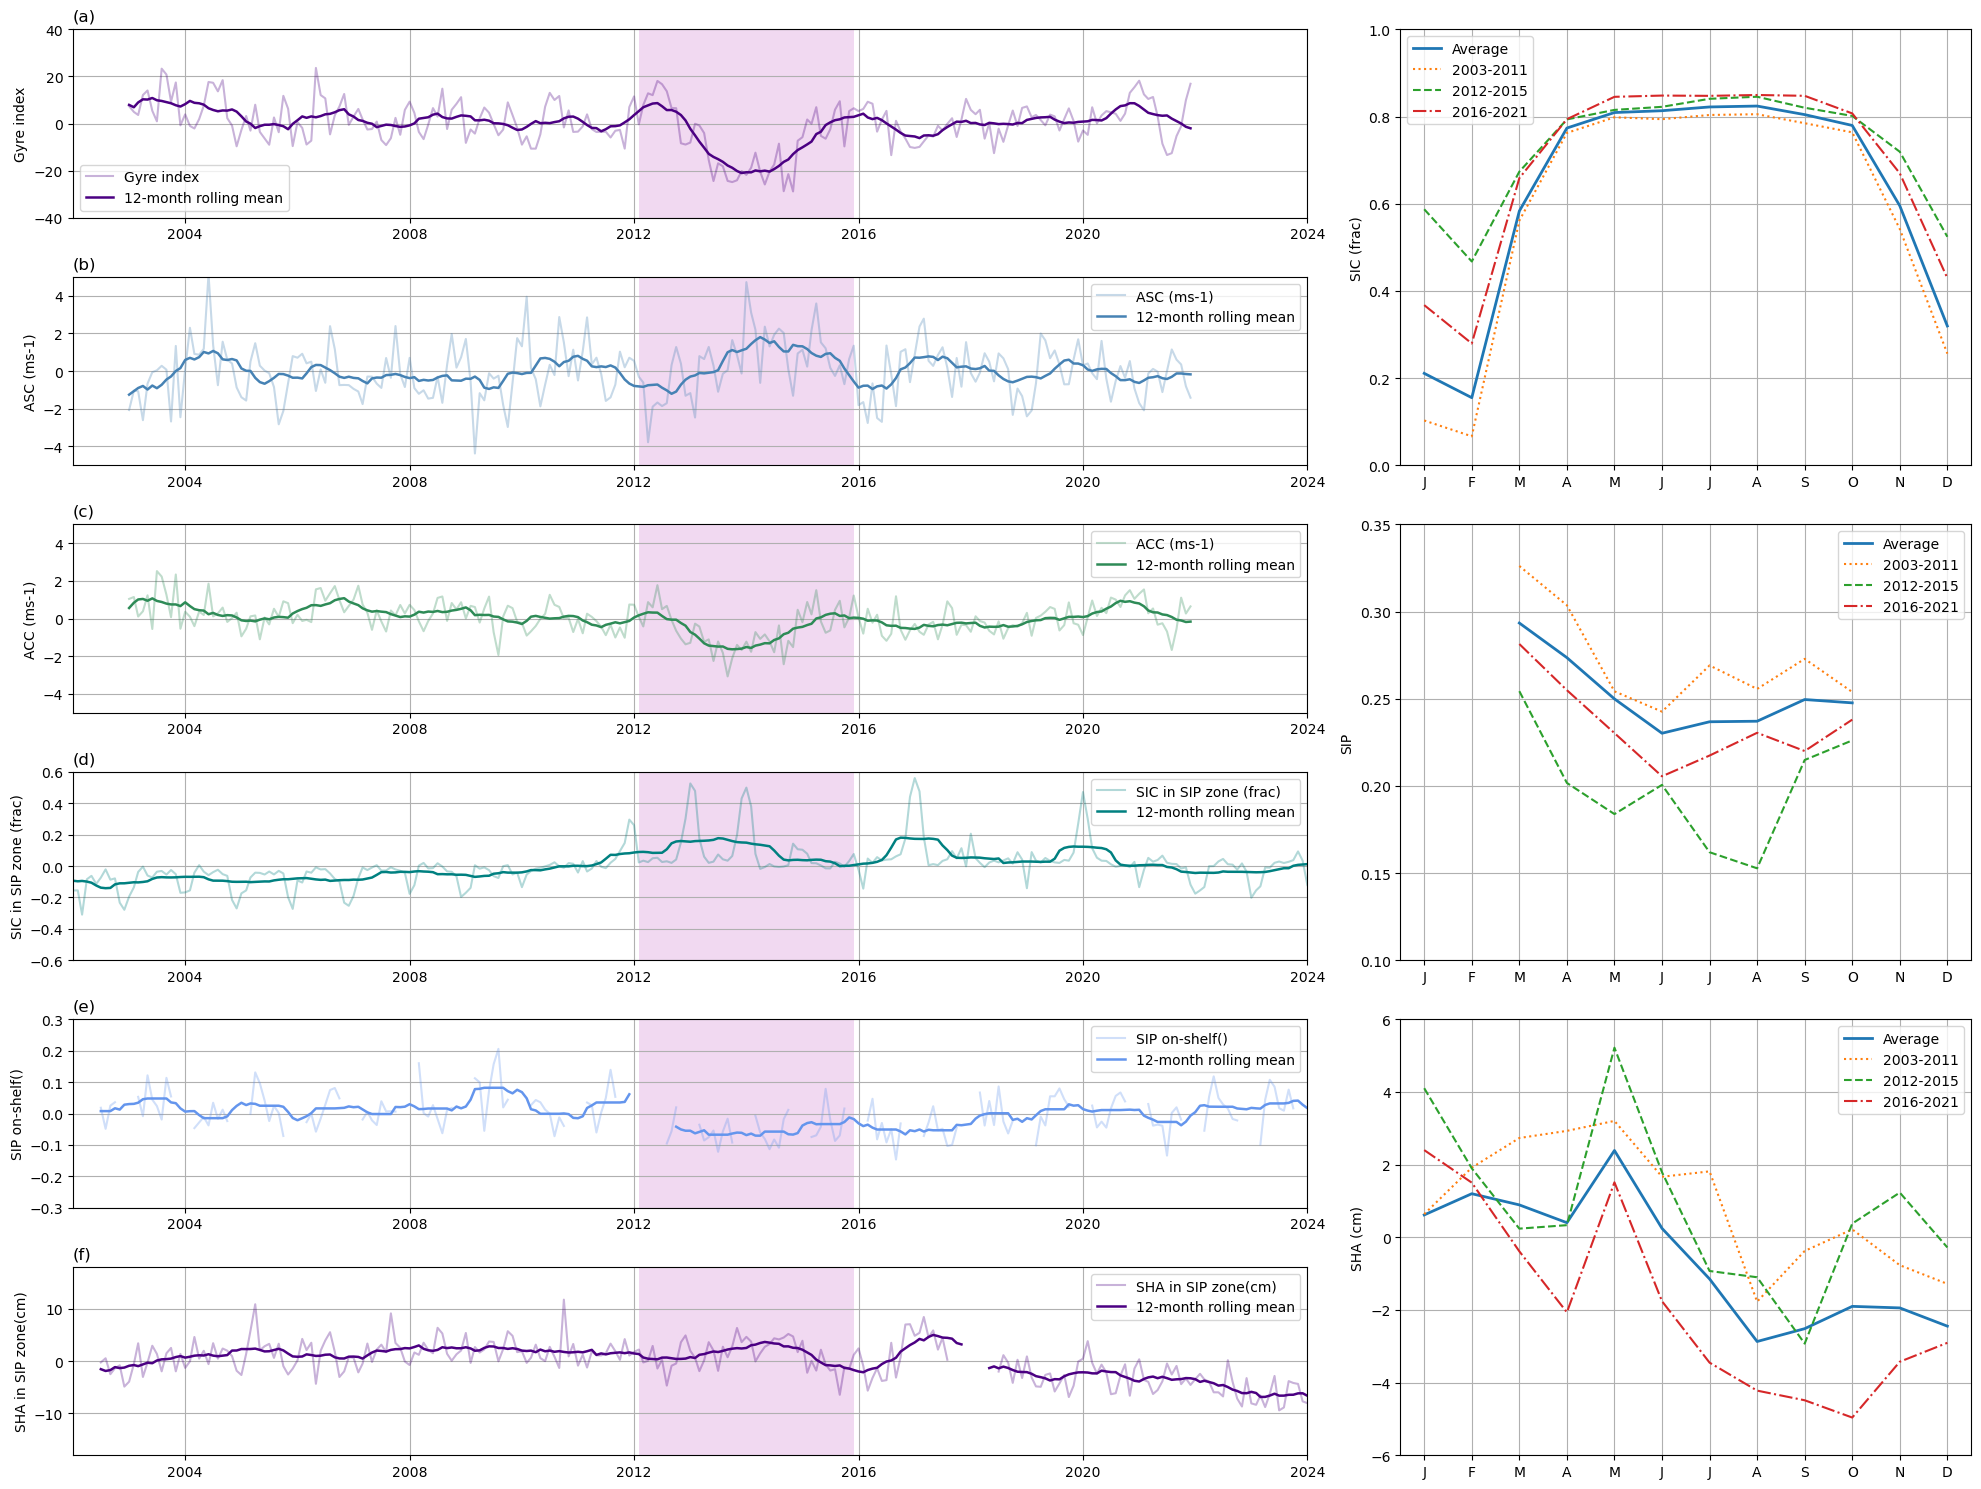

In [28]:
t0 = acc.time[0]
t1 = pd.Timestamp(2012,12,31)
t2 = pd.Timestamp(2015,12,31)
t3 = acc.time[-1]


fig = plt.figure(figsize=(20,15))
axs=[]

gs = fig.add_gridspec(6,6)

def add_row(n,var,varname,ylim=[-16,16],anom=False,cvar=None,cvarname=None,cvarlim=None,title='None',color='indigo'):

    axs.append(fig.add_subplot(gs[n,0:4]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var

    cmt = da.groupby('time.month').mean()


    ax = axs[len(axs)-1]

    if anom:
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname,c=color,alpha=0.3)
    ax.plot(da.time,da.rolling(time=12,center=True,min_periods=4).mean(),label='12-month rolling mean',c=color,linewidth=1.8)

    ax.set_ylabel(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    for y,c in zip([2012],['coral']):#@2007,2011,2014,2017],colors):
        t1a = pd.Timestamp(y,1,1)
        t1b = pd.Timestamp(y+4,1,1)
        tboo = (da.time > t1a) & (da.time < t1b)
        
        ax.fill_between(da.time, ylim[0],ylim[1], where=tboo, alpha=0.4, facecolor='plum',label='spring '+str(y))
        ax.set_title(title,loc='left')
    
    if cvar is not None:
        axs.append(fig.add_subplot(gs[n:n+2,4:6]))

    
        cmt = cvar.groupby('time.month').mean()
        cmt1 = cvar.sel(time=slice(t0,t1)).groupby('time.month').mean()
        cmt2 = cvar.sel(time=slice(t1,t2)).groupby('time.month').mean()
        cmt3 = cvar.sel(time=slice(t2,t3)).groupby('time.month').mean()

        ax = axs[len(axs)-1]

        ax.plot(cmt.month,cmt,linewidth=2,label='Average')

        ax.plot(cmt.month,cmt1,linestyle=':',label='2003-2011')
        ax.plot(cmt.month,cmt2,linestyle='--',label='2012-2015')
        ax.plot(cmt.month,cmt3,linestyle='-.',label='2016-2021')
        ax.set_ylim(cvarlim)
        ax.grid()
        ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
        ax.set_xlim([0.5,12.5])
        ax.legend()
        ax.set_ylabel(cvarname)




add_row(0,gyre_index,'Gyre index',anom=True,ylim=[-40,40],cvar=csic,cvarname='SIC (frac)',cvarlim=[0,1],title='(a)',color='indigo')
add_row(1,asc,'ASC (ms-1)',anom=True,ylim=[-5,5],title='(b)',color='steelblue') # (geostrophic gradient on slope)
add_row(2,acc,'ACC (ms-1)',anom=True,ylim=[-5,5],cvar=csip,cvarname='SIP',cvarlim=[0.1,0.35],title='(c)',color='seagreen') # (geostrophic gradient at 63-65S)
add_row(3,csic,'SIC in SIP zone (frac)',anom=True,ylim=[-0.6,0.6],title='(d)',color='teal')
add_row(4,csip,'SIP on-shelf()',anom=True,ylim=[-0.3,0.3],cvar=csha,cvarname='SHA (cm)',cvarlim=[-6,6],title='(e)',color='cornflowerblue')
add_row(5,csha,'SHA in SIP zone(cm)',anom=True,ylim=[-18,18],title='(f)')



plt.tight_layout()
print('Rendering..')


Rendering..


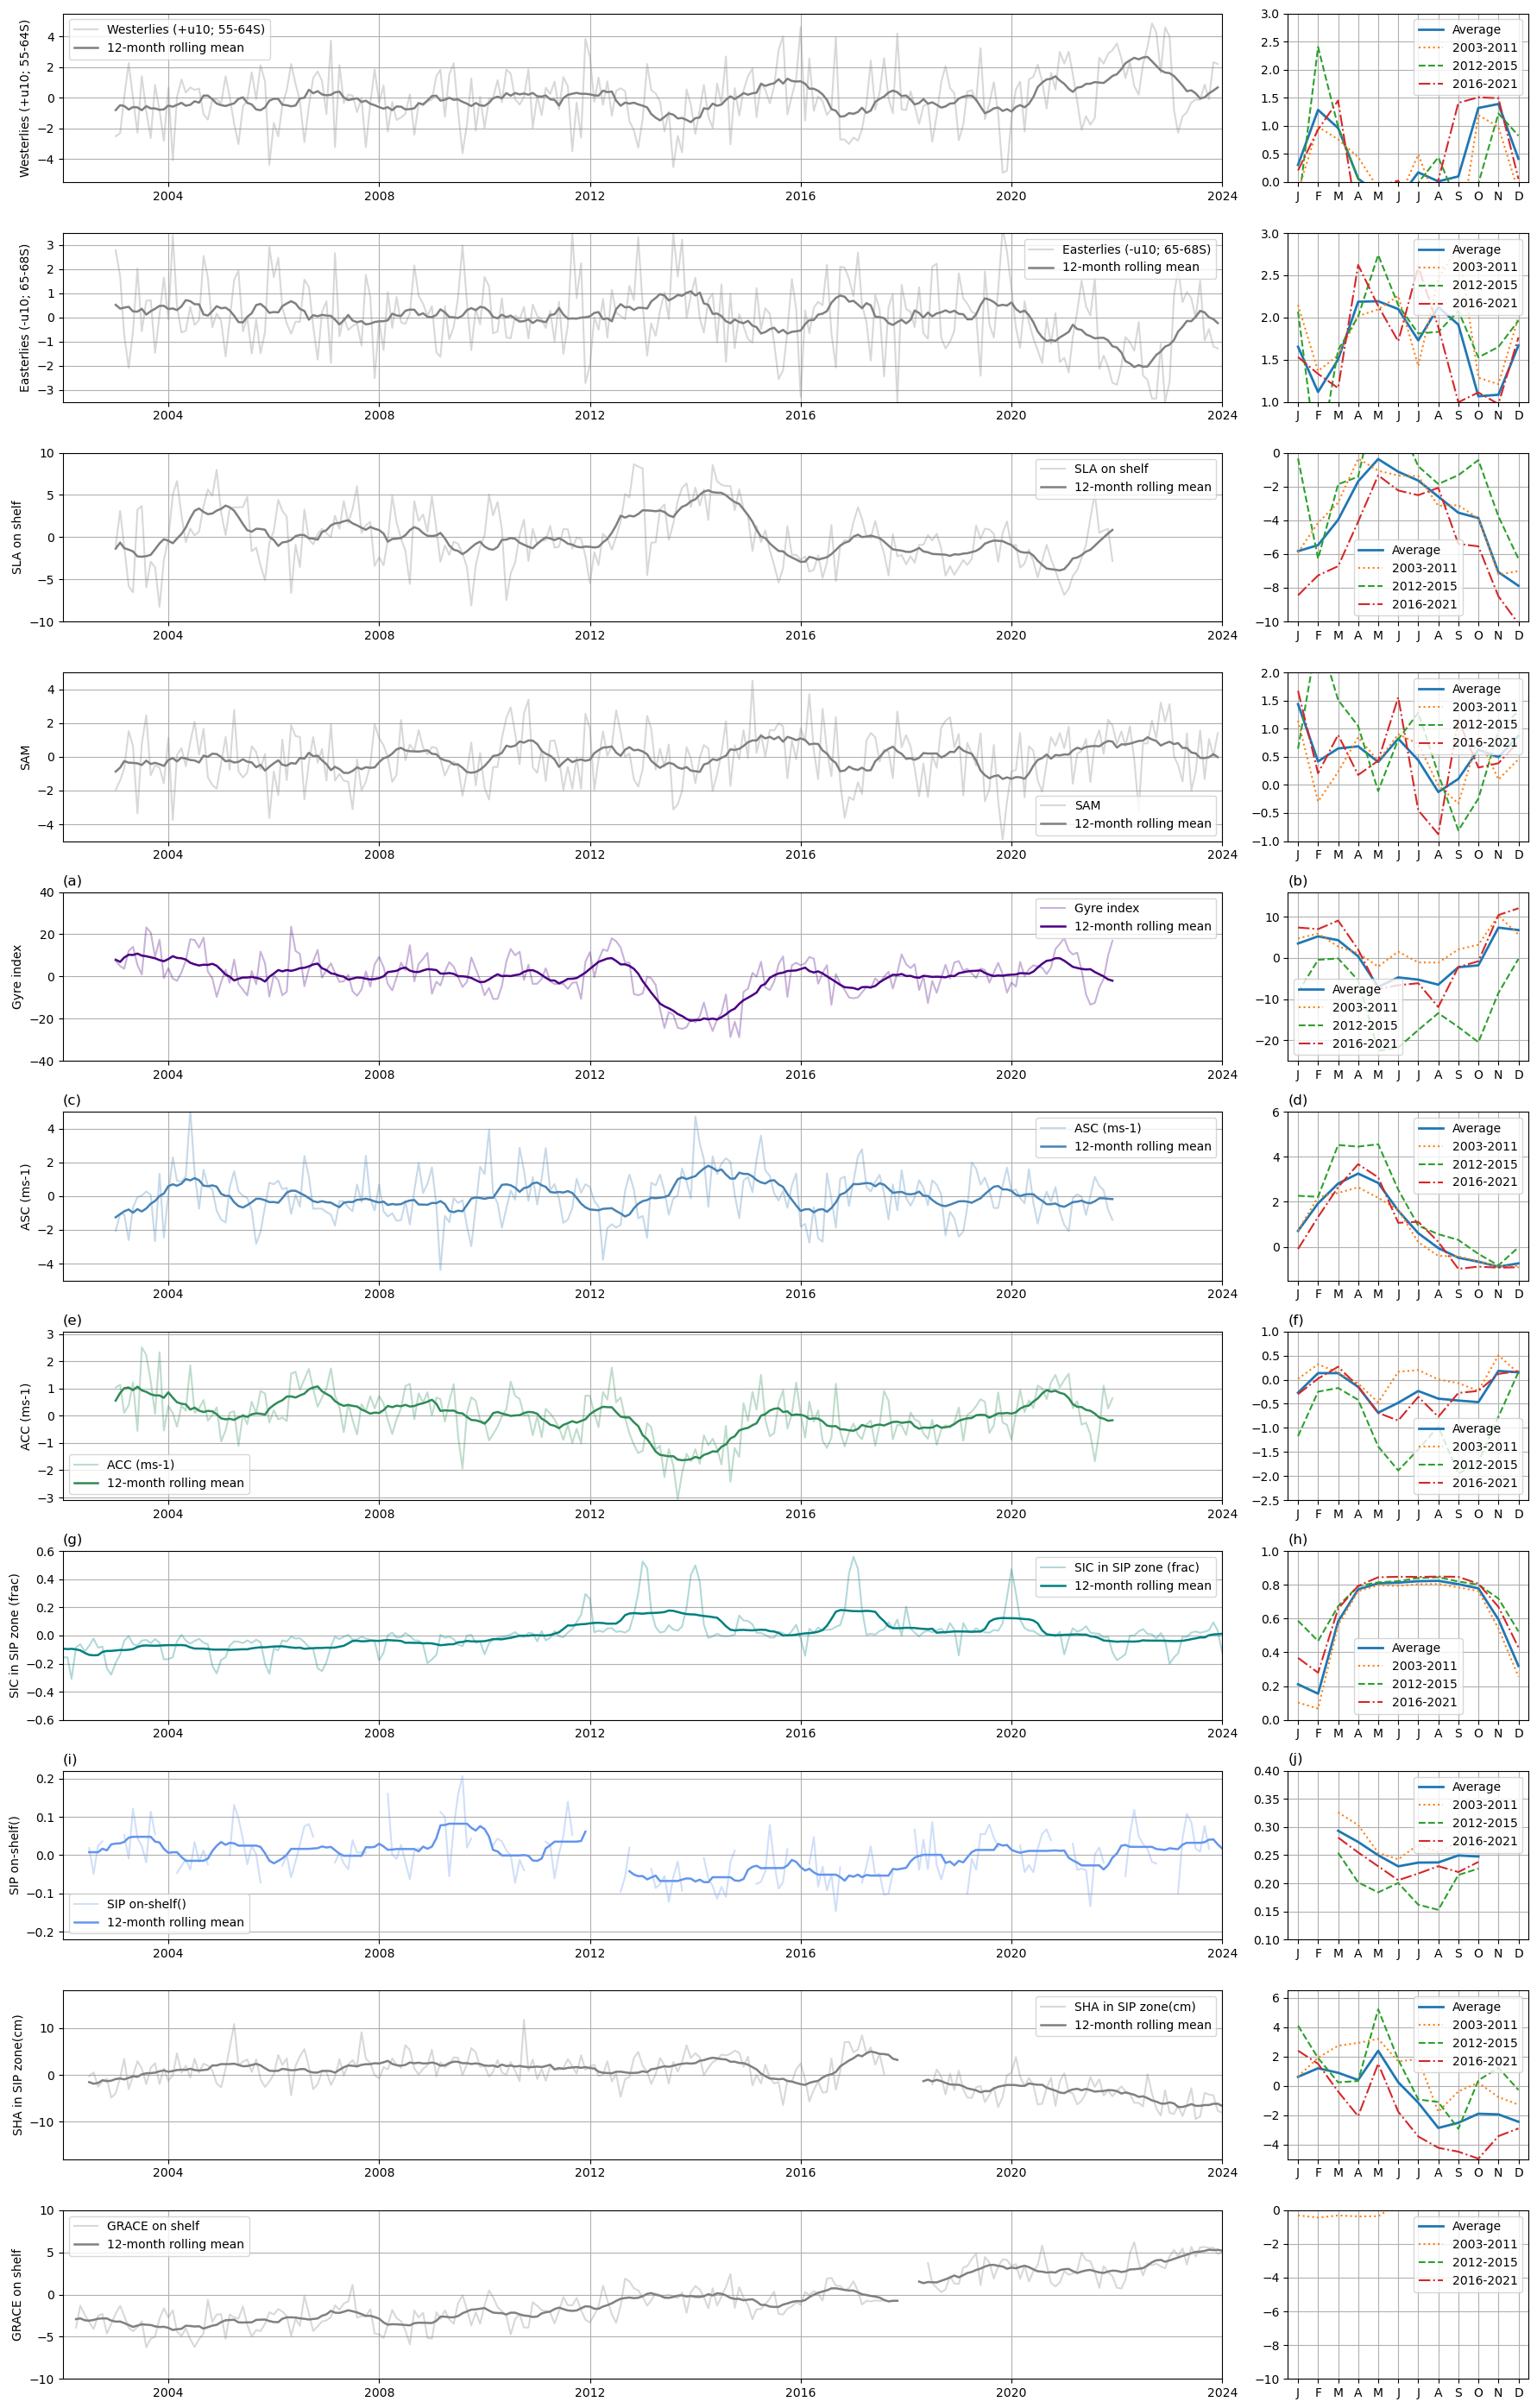

In [33]:
t0 = acc.time[0]
t1 = pd.Timestamp(2012,12,31)
t2 = pd.Timestamp(2015,12,31)
t3 = acc.time[-1]


fig = plt.figure(figsize=(18,28))
axs=[]

gs = fig.add_gridspec(11,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False,titles=[None,None],color='grey'):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    cmt1 = da.sel(time=slice(t0,t1)).groupby('time.month').mean()
    cmt2 = da.sel(time=slice(t1,t2)).groupby('time.month').mean()
    cmt3 = da.sel(time=slice(t2,t3)).groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        #varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname,c=color,alpha=0.3)
    ax.plot(da.time,da.rolling(time=12,center=True,min_periods=4).mean(),label='12-month rolling mean',c=color,linewidth=1.8)

    ax.set_ylabel(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()
    ax.set_title(titles[0],loc='left')

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt,linewidth=2,label='Average')

    ax.plot(cmt.month,cmt1,linestyle=':',label='2003-2011')
    ax.plot(cmt.month,cmt2,linestyle='--',label='2012-2015')
    ax.plot(cmt.month,cmt3,linestyle='-.',label='2016-2021')
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])
    ax.legend()
    ax.set_title(titles[1],loc='left')



add_row(0,westl,'Westerlies (+u10; 55-64S)',anom=True,ylim=[-5.5,5.5],ylim_cmt=[0,3])
add_row(1,eastl,'Easterlies (-u10; 65-68S)',anom=True,ylim=[-3.5,3.5],ylim_cmt=[1,3])
add_row(2,cssh,'SLA on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])
add_row(3,sam,'SAM',anom=True,ylim=[-5,5],ylim_cmt=[-1,2])
add_row(4,gyre_index,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-25,16],titles=['(a)','(b)'],color='indigo')
add_row(5,asc,'ASC (ms-1)',anom=True,ylim=[-5,5],ylim_cmt=[-1.5,6],titles=['(c)','(d)'],color='steelblue') # (geostrophic gradient on slope)
add_row(6,acc,'ACC (ms-1)',anom=True,ylim=[-3.1,3.1],ylim_cmt=[-2.5,1],titles=['(e)','(f)'],color='seagreen') # (geostrophic gradient at 63-65S)
add_row(7,csic,'SIC in SIP zone (frac)',anom=True,ylim=[-0.6,0.6],ylim_cmt=[0,1],titles=['(g)','(h)'],color='teal')
add_row(8,csip,'SIP on-shelf()',anom=True,ylim=[-0.22,0.22],ylim_cmt=[0.1,0.4],titles=['(i)','(j)'],color='cornflowerblue')
add_row(9,csha,'SHA in SIP zone(cm)',anom=True,ylim=[-18,18],ylim_cmt=[-5,6.5])
add_row(10,clwe,'GRACE on shelf',anom=True,ylim=[-10,10],ylim_cmt=[-10,0])




plt.tight_layout()
print('Rendering..')


In [30]:
#repeat with extra plots
sose140 = xr.open_dataset('sose_shelf_140.nc')
sose145 = xr.open_dataset('sose_shelf_145.nc')

In [31]:
sigdiff = xr.open_dataarray('sigdiff.nc')

In [40]:
#repeat with extra plots
glorys = xr.open_dataset('glorys_shelf_140.nc')

In [41]:
mglorys = glorys.mean(['latitude','longitude','depth'])

In [42]:
glorys

<xarray.Dataset> Size: 4GB
Dimensions:       (time: 228, latitude: 55, longitude: 168, depth: 35)
Coordinates:
  * time          (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2021-12-01
  * latitude      (latitude) float32 220B -67.5 -67.42 -67.33 ... -63.08 -63.0
  * longitude     (longitude) float32 672B 138.0 138.1 138.2 ... 151.8 151.9
  * depth         (depth) float32 140B 0.494 1.541 2.646 ... 643.6 763.3 902.3
    month         (time) int64 2kB ...
Data variables: (12/14)
    siconc        (time, latitude, longitude, depth) float32 295MB nan ... nan
    mlotst        (time, latitude, longitude, depth) float32 295MB nan ... 11.74
    sithick       (time, latitude, longitude, depth) float32 295MB nan ... nan
    zos           (time, latitude, longitude, depth) float32 295MB nan ... -0...
    thetao        (time, depth, latitude, longitude) float32 295MB nan ... 0....
    so            (time, depth, latitude, longitude) float32 295MB nan ... 0....
    ...            ...
    vo            (time, depth, latitude, longitude) float32 295MB nan ... -0...
    asc_latitude  (time, longitude, depth) float64 11MB 0.0 0.0 0.0 ... 0.0 0.0
    asc           (time, depth, longitude) float32 5MB -0.031 ... -0.006232
    pressure      (time, depth) float64 64kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    rho           (time, depth, latitude, longitude) float64 590MB nan ... nan
    sigma0        (time, depth, latitude, longitude) float64 590MB nan ... 0....
Attributes:
    Conventions:       CF-1.11
    title:             Monthly mean fields for product GLOBAL_REANALYSIS_PHY_...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MERCATOR GLORYS12V1
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1M-m_202311
    subset:date:       2025-12-04T07:49:47.532Z

In [43]:
vars = [cssh,asc,csic,sose145.THETA.mean(['Z','YC']),sose145.SALT.mean(['Z','YC']),mglorys.thetao,mglorys.so]
cmat = np.empty((len(vars),len(vars)))
pmat = np.empty((len(vars),len(vars)))

# vars = []

# for v in vars_:
#     cmt = v.groupby('time.month').mean()
#     var = (v-cmt).rolling({'time':12},center=True).mean()
#     vars.append(var)
ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(vars):
        vw, wv = xr.align(v,w)
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [44]:
matt = pd.DataFrame(cmat,columns=['SLA','ASC','SIC','SOSE T','SOSE S','GLORYS T','GLORYS S'],index=['SLA','ASC','SIC','SOSE T','SOSE S','GLORYS T','GLORYS S'])

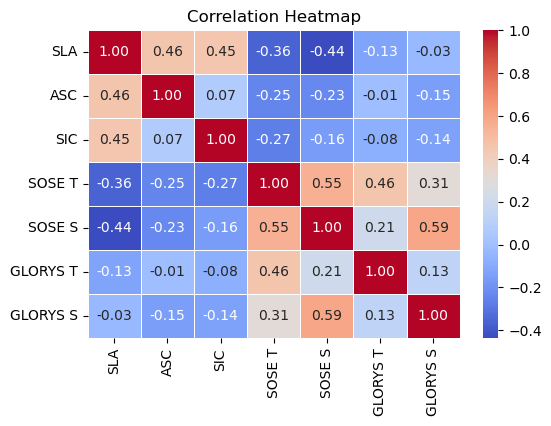

In [45]:

plt.figure(figsize=(6,4))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [46]:
ssal = sose145.SALT.sel(Z=slice(0,-500)).mean(['Z','YC'])
sthe = sose145.THETA.sel(Z=slice(0,-500)).mean(['Z','YC'])

In [47]:

var1 = fns.seasonal_anomaly(ssal)# sose145.SALT.integrate('Z').mean(['YC']
vars = [fns.seasonal_anomaly(var) for var in [cssh,westl,eastl,asc,sam,acc,csic]]


lags = np.arange(-12,13,1)
cmat = np.empty((len(vars),len(lags)))
pmat = np.empty((len(vars),len(lags)))


ts = cssh.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(lags):
        var1_shifted = var1.assign_coords(
            time=pd.to_datetime(var1.time.values) + pd.DateOffset(months=w)
        )
        vw, wv = xr.align(v,var1_shifted)#.shift({'time':w}))
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [48]:
matt = pd.DataFrame(cmat.T,columns=['SLA','W-LIES','E-LIES','ASC','SAM','ACC','SIC'],index=[str(n) for n in lags])

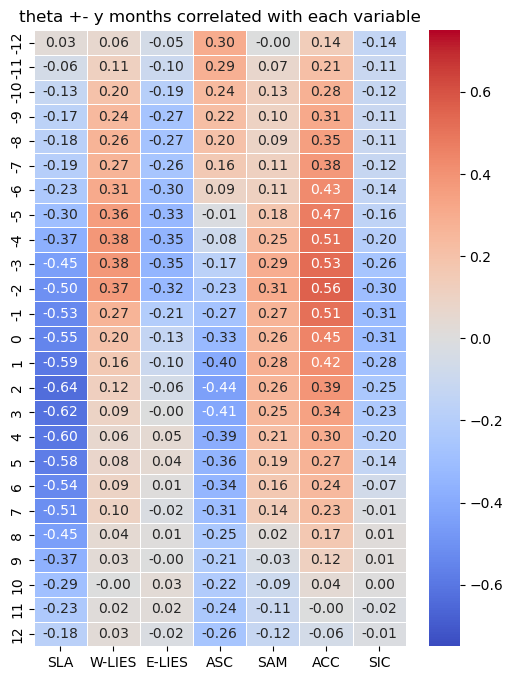

In [49]:
plt.figure(figsize=(6,8))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-0.75,vmax=0.75)
plt.title("theta +- y months correlated with each variable")
plt.show()

In [33]:
def mshift(da,m):
    return da.assign_coords(
            time=pd.to_datetime(da.time.values) + pd.DateOffset(months=m)
        )

def laglbl(lag):
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    return txt

In [34]:
vars = [fns.seasonal_anomaly(var) for var in [westl,eastl,cssh,asc,acc,sam,csic,csip,gssh,gyre_index]]#,sigdiff]]
lags = np.arange(-6,7,1)

cmat = np.empty((len(vars),len(vars)))
lmat = np.empty((len(vars),len(vars)))


ts = cssh.time[0]

for i,var1 in enumerate(vars):
    cmatl = np.empty((len(lags)))

    for j,v in enumerate(vars):
        for k,w in enumerate(lags):
            vw, wv = xr.align(v,mshift(var1,w))#var1.shift({'time':w}))
            cmatl[k] = xr.corr(vw,wv).item()
        abs_cmatl = np.abs(cmatl)
        cmat[i][j] = cmatl[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]
        lmat[i][j] = lags[max(range(len(abs_cmatl)), key=abs_cmatl.__getitem__)]

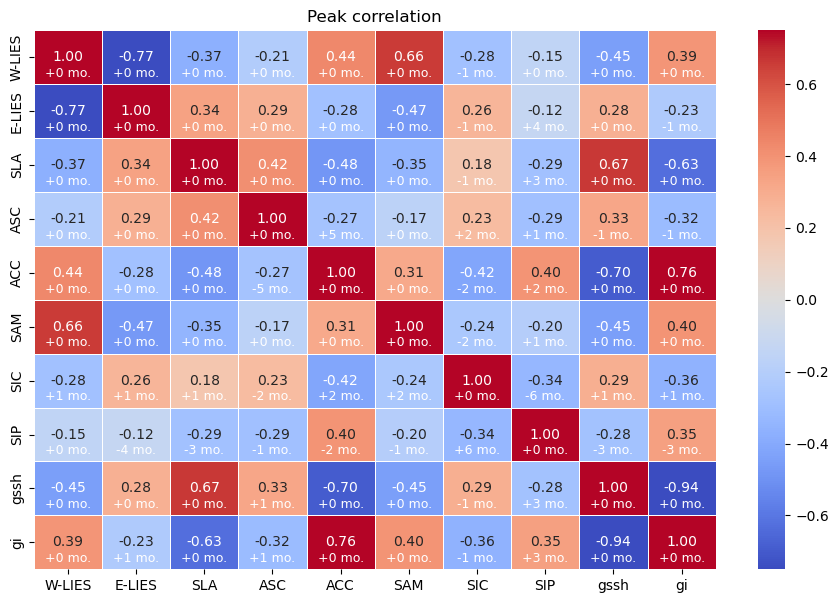

In [35]:
lbls = ['W-LIES','E-LIES','SLA','ASC','ACC','SAM','SIC','SIP','gssh','gi']
matt = pd.DataFrame(cmat,columns=lbls,index=lbls)

fig,ax = plt.subplots(figsize=(11,7))
sns.heatmap(matt, ax=ax, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-0.75,vmax=0.75)
ax.set_title("Peak correlation")

#matl = pd.DataFrame(lmat,columns=lbls,index=lbls)
# plt.figure(figsize=(6,4))
# sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,vmin=-12,vmax=23)
# plt.title("Correlation Heatmap")
# plt.show()

#ax=plt.gca()

for i in range (lmat.shape[0]):
  for j in range(lmat.shape[1]):
    lag = lmat[i,j]
    if lag >-1:
      txt = f'+{lag:.0f} mo.'
    else:
      txt = f'{lag:.0f} mo.'
    ax.text(i + 0.5, j + 0.8, txt,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=9,
            color='w')

In [36]:
a = fns.seasonal_anomaly(gyre_index)
alabel='GI'
b = fns.seasonal_anomaly(sthe)
blabel='SHELF theta'
lag=2

a,b = xr.align(a,b)
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')

twin2=ax.twinx()
twin2.spines.right.set_position(("axes", 1.2))

l3 = twin2.plot(csic.time,csic.rolling({'time':12},center=True).mean(),c='lightblue')
ax.legend(l1+l2,[alabel,blabel])

a,b = xr.align(a,mshift(b,lag))
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])

NameError: name 'sthe' is not defined

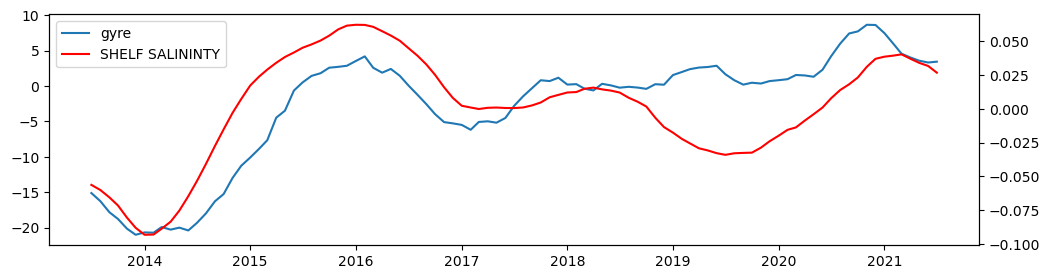

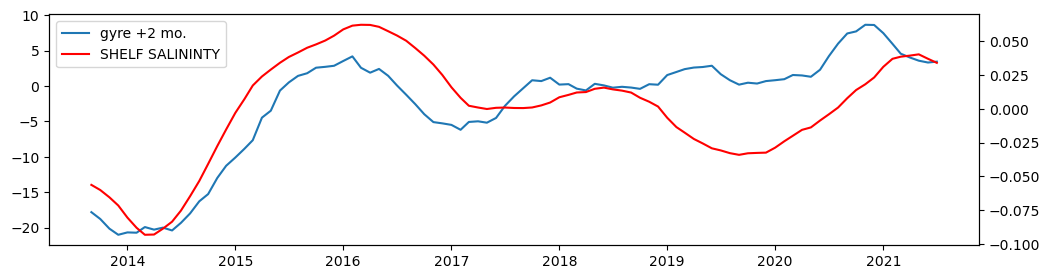

In [50]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre'
b = fns.seasonal_anomaly(ssal)
blabel='SHELF SALININTY'
lag=2

a,b = xr.align(a,b)
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

a,b = xr.align(a,mshift(b,lag))
fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel + ' ' + laglbl(lag),blabel])


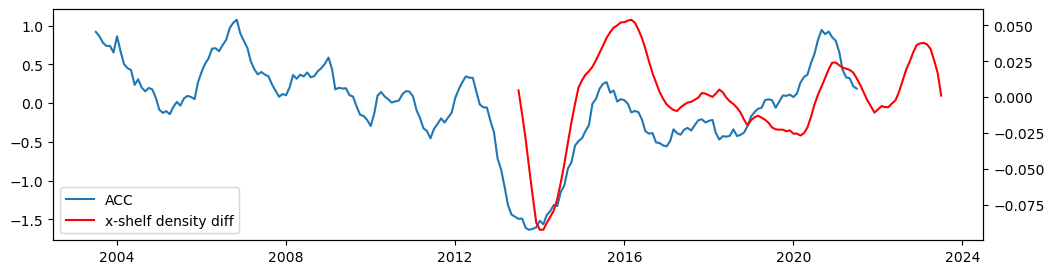

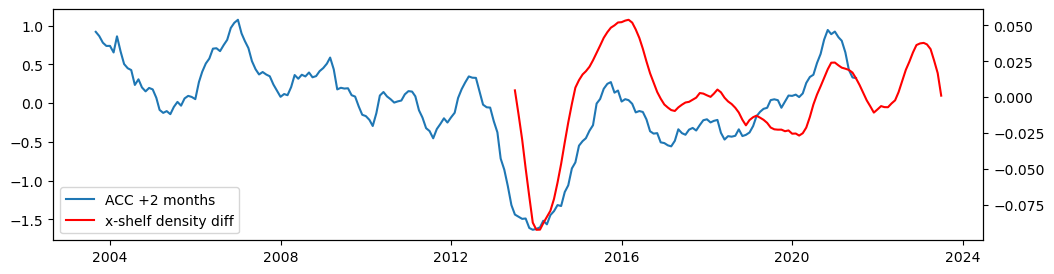

In [46]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

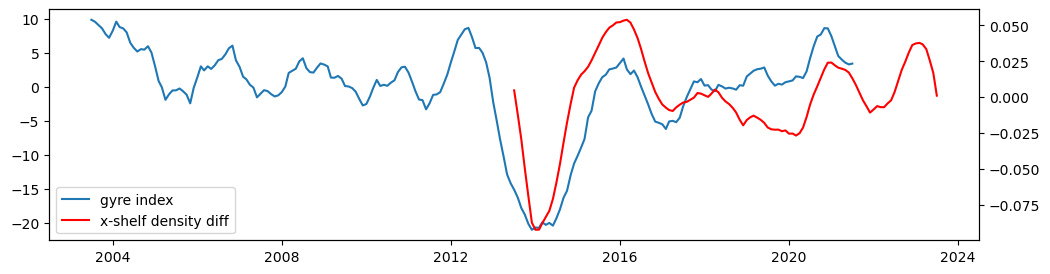

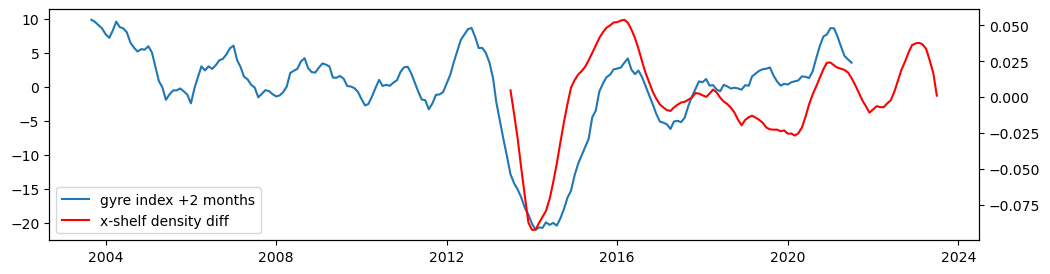

In [47]:
a = fns.seasonal_anomaly(gyre_index)
alabel='gyre index'
b = fns.seasonal_anomaly(sigdiff)
blabel='x-shelf density diff'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

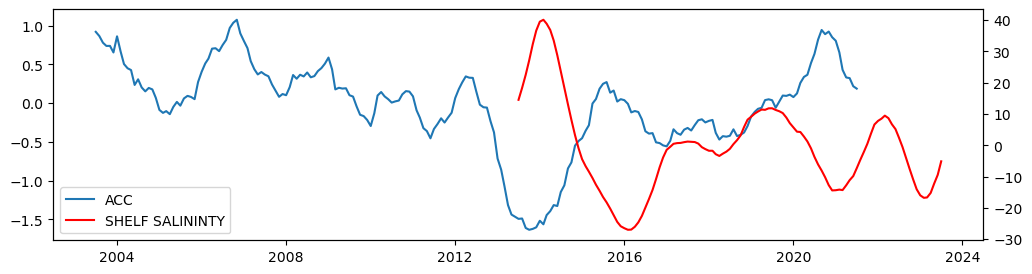

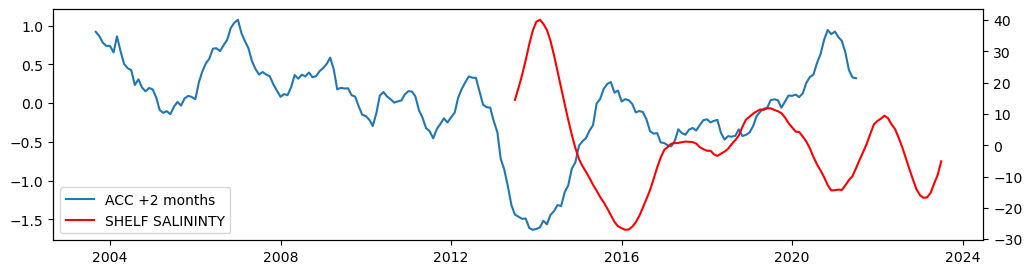

In [48]:
a = fns.seasonal_anomaly(acc)
alabel='ACC'
b = fns.seasonal_anomaly(sose145.SALT.integrate('Z').mean(['YC']))
blabel='SHELF SALININTY'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.shift({'time':2}).rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel+ ' +2 months',blabel])

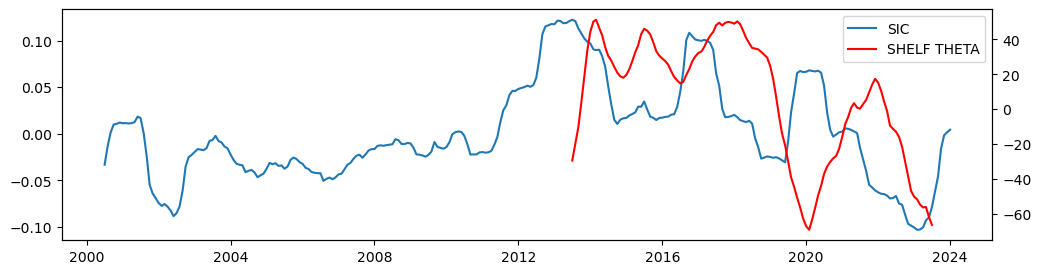

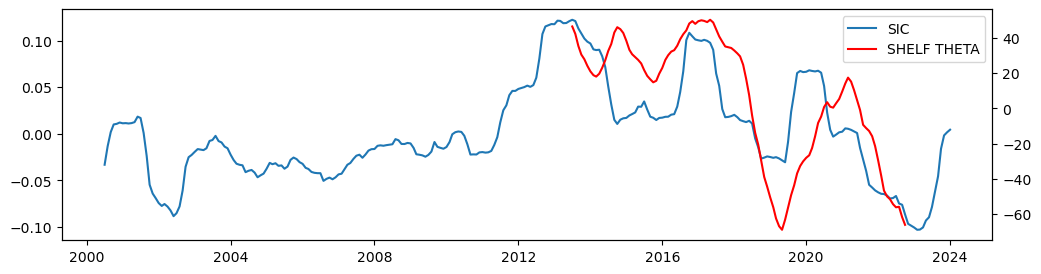

In [49]:
a = fns.seasonal_anomaly(csic)
alabel='SIC'
b = fns.seasonal_anomaly(sose145.THETA.integrate('Z').mean(['YC']))
blabel='SHELF THETA'

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])

fig, ax = plt.subplots(1,1,figsize=(12,3))
l1=ax.plot(a.time,a.rolling({'time':12},center=True).mean())
l2=ax.twinx().plot(b.time,b.shift({'time':-9}).rolling({'time':12},center=True).mean(),c='r')
ax.legend(l1+l2,[alabel,blabel])


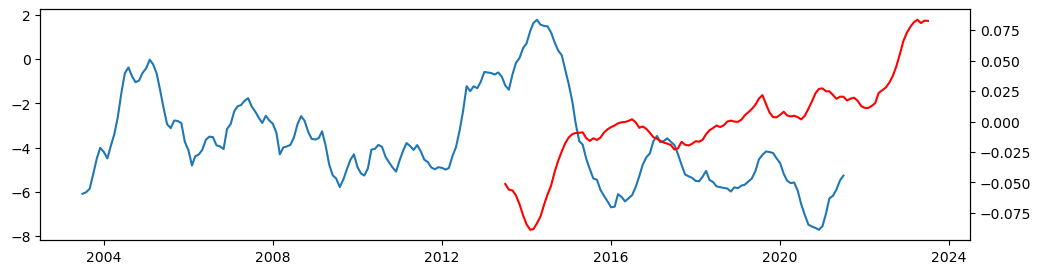

In [50]:
fig, ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(cssh.time,cssh.rolling({'time':12},center=True).mean())
ax.twinx().plot(var1.time,var1.rolling({'time':12},center=True).mean(),c='r')